

1.   Load data
2. Speaker detection
3. Speaker distribution (value counts)
4. Word frequency — Krishna vs Arjuna comparison
5. GoEmotions on all 700 verses — psychological map heatmap
6. Krishna emotional arc by chapter
7. Arjuna emotional arc by chapter (correct — using Speaker column)
8. LDA — thematic analysis
10. Readability analysis



# **SECTION 1 - Load data**

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from collections import Counter
from nltk.corpus import stopwords

a = pd.read_csv('https://raw.githubusercontent.com/i8o8i-Developer/Bhagwat-Gita-DataSet/refs/heads/main/Main.csv')
a_english = a[['Title', 'Chapter', 'Verse', 'Enlgish Translation']]
print(a_english.shape)
a_english.head()

(700, 4)


,Title,Chapter,Verse,Enlgish Translation
0,Arjuna's Vishada Yoga,Chapter 1,Verse 1.1,"Dhrtarashtra asked of Sanjaya: O SANJAYA, what..."
1,Arjuna's Vishada Yoga,Chapter 1,Verse 1.2,Sanjaya explained: Now seeing that the army of...
2,Arjuna's Vishada Yoga,Chapter 1,Verse 1.3,"Behold O, Master, the mighty army of the sons ..."
3,Arjuna's Vishada Yoga,Chapter 1,Verse 1.4,"Present here are the mighty archers, peers or ..."
4,Arjuna's Vishada Yoga,Chapter 1,Verse 1.5,"Dhrishtaketu, Chekitana, and the valiant king ..."


# **SECTION 2 — Speaker Detection**



In [ ]:
import spacy
nlp = spacy.load('en_core_web_sm')

speech_verbs = ['speak', 'explain', 'ask', 'say', 'tell', 'instruct',
                'call', 'name', 'conclude', 'continue', 'reply',
                'declare', 'proclaim', 'narrate', 'recount', 'state']

pronouns = ['I', 'he', 'she', 'they', 'you', 'we', 'it', 'He', 'She',
            'son', 'You', 'Brahma', 'Thay', 'Men', 'people']

speakers = []
last_speaker = 'UNKNOWN'

for verse in a_english['Enlgish Translation']:
    detected = None
    doc = nlp(verse)

    for token in doc:
        if token.lemma_ in speech_verbs:
            speech_verb = token
            for other_token in doc:
                if other_token.dep_ == "nsubj" and other_token.head == speech_verb:
                    detected = other_token.text
                    if detected in pronouns:
                        detected = None
                    break
        if detected:
            break

    if detected:
        last_speaker = detected
        speakers.append(detected)
    else:
        speakers.append(last_speaker)

a_english['Speaker'] = speakers

# Clean up speaker names
speaker_map = {
    'Lord': 'Krishna',
    'lord': 'Krishna',
    'HRISHIKESA': 'Krishna',
    'Almighty': 'Krishna',
    'Krishna': 'Krishna',
    'Sanjay': 'Sanjaya',
    'Sanjaya': 'Sanjaya',
    'Arjuna': 'Arjuna',
    'Duryodhana': 'Duryodhana',
    'Dhrtarashtra': 'Dhrtarashtra',
}

a_english['Speaker'] = a_english['Speaker'].map(speaker_map).fillna(a_english['Speaker'])
print(a_english['Speaker'].unique())

['Dhrtarashtra' 'Sanjaya' 'Duryodhana' 'Arjuna' 'Krishna']


/tmp/ipykernel_389/1805526029.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a_english['Speaker'] = speakers
/tmp/ipykernel_389/1805526029.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a_english['Speaker'] = a_english['Speaker'].map(speaker_map).fillna(a_english['Speaker'])


# **SECTION 3 -   Speaker Distribution**



/tmp/ipykernel_389/1836358811.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=speaker_counts.index, y=speaker_counts.values, palette='muted')


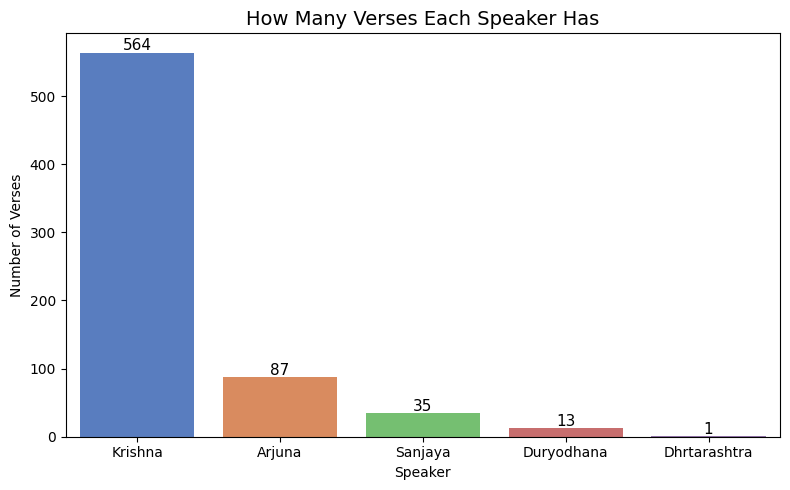

In [ ]:
speaker_counts = a_english['Speaker'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=speaker_counts.index, y=speaker_counts.values, palette='muted')
plt.title('How Many Verses Each Speaker Has', fontsize=14)
plt.xlabel('Speaker')
plt.ylabel('Number of Verses')
for i, v in enumerate(speaker_counts.values):
    plt.text(i, v + 3, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

# **SECTION 4 — Word Frequency: Krishna vs Arjuna**


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


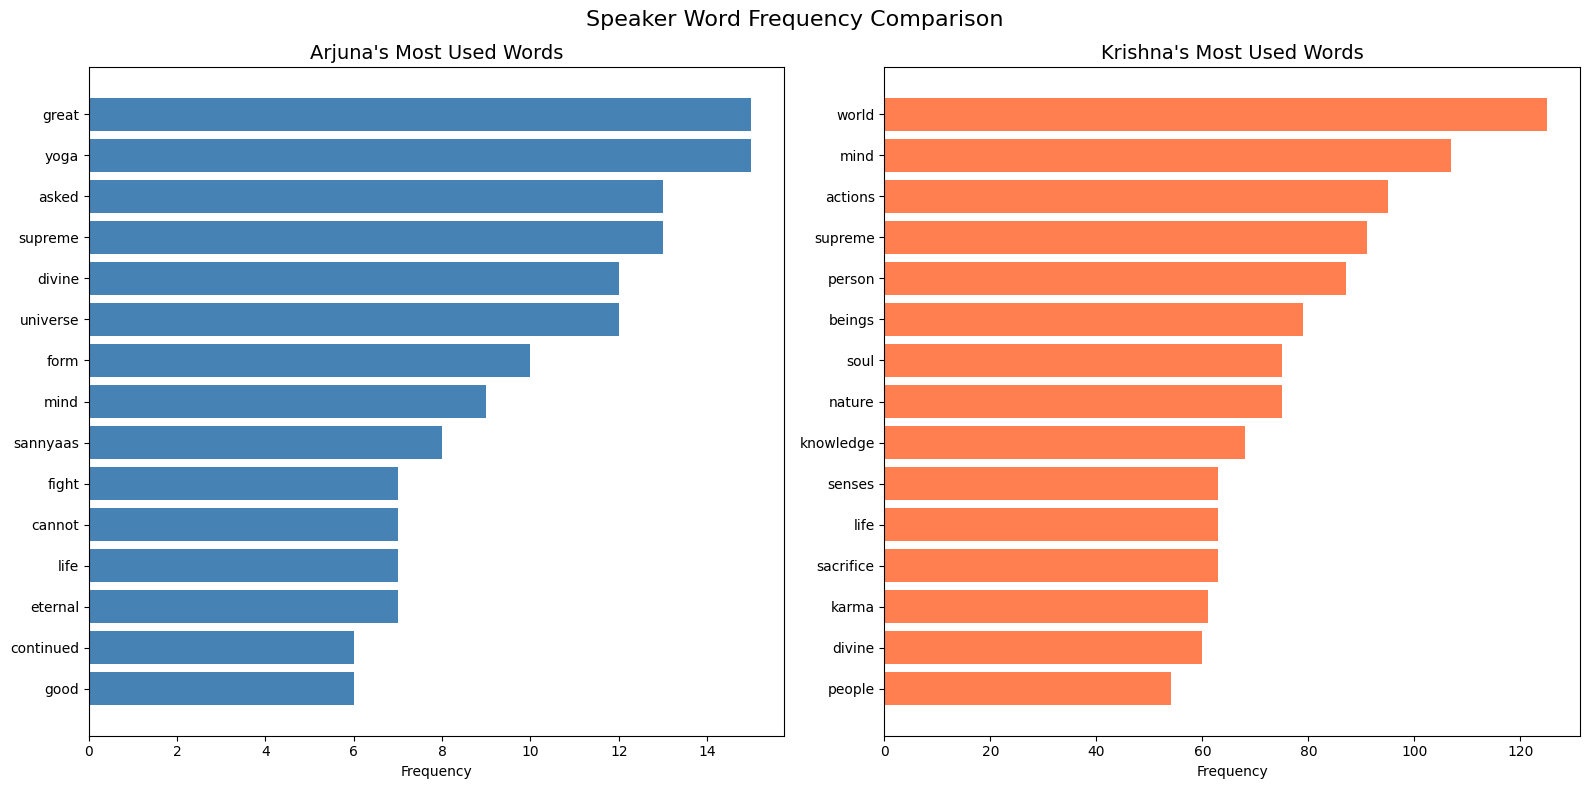

In [ ]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
stop_words.update(['o', 'thy', 'ye', 'thee', 'thou', 'arjuna', 'krishna',
                   'lord', 'dear', 'said', 'shall', 'upon', 'unto', 'also',
                   'thus', 'even', 'like', 'well', 'must', 'ever'])

a_arjuna_english = a_english[a_english['Speaker'] == 'Arjuna']
a_krishna_english = a_english[a_english['Speaker'] == 'Krishna']

def get_word_list(df):
    words = []
    for verse in df['Enlgish Translation']:
        verse = verse.lower()
        verse = re.sub(r'[^a-zA-Z\s]', '', verse)
        filtered = [w for w in verse.split() if w not in stop_words and len(w) > 3]
        words.extend(filtered)
    return words

listt_arjuna = get_word_list(a_arjuna_english)
listt_krishna = get_word_list(a_krishna_english)

arjuna_top = Counter(listt_arjuna).most_common(15)
krishna_top = Counter(listt_krishna).most_common(15)

arjuna_words, arjuna_counts = zip(*arjuna_top)
krishna_words, krishna_counts = zip(*krishna_top)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

ax1.barh(arjuna_words, arjuna_counts, color='steelblue')
ax1.set_title("Arjuna's Most Used Words", fontsize=14)
ax1.set_xlabel('Frequency')
ax1.invert_yaxis()

ax2.barh(krishna_words, krishna_counts, color='coral')
ax2.set_title("Krishna's Most Used Words", fontsize=14)
ax2.set_xlabel('Frequency')
ax2.invert_yaxis()

plt.suptitle('Speaker Word Frequency Comparison', fontsize=16)
plt.tight_layout()
plt.show()

# **SECTION 5 — GoEmotions on All 700 Verses (Psychological Map)**



config.json:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

/tmp/ipykernel_389/1427796569.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a_english['emotion'] = [verse[0]['label'] for verse in raw_results]


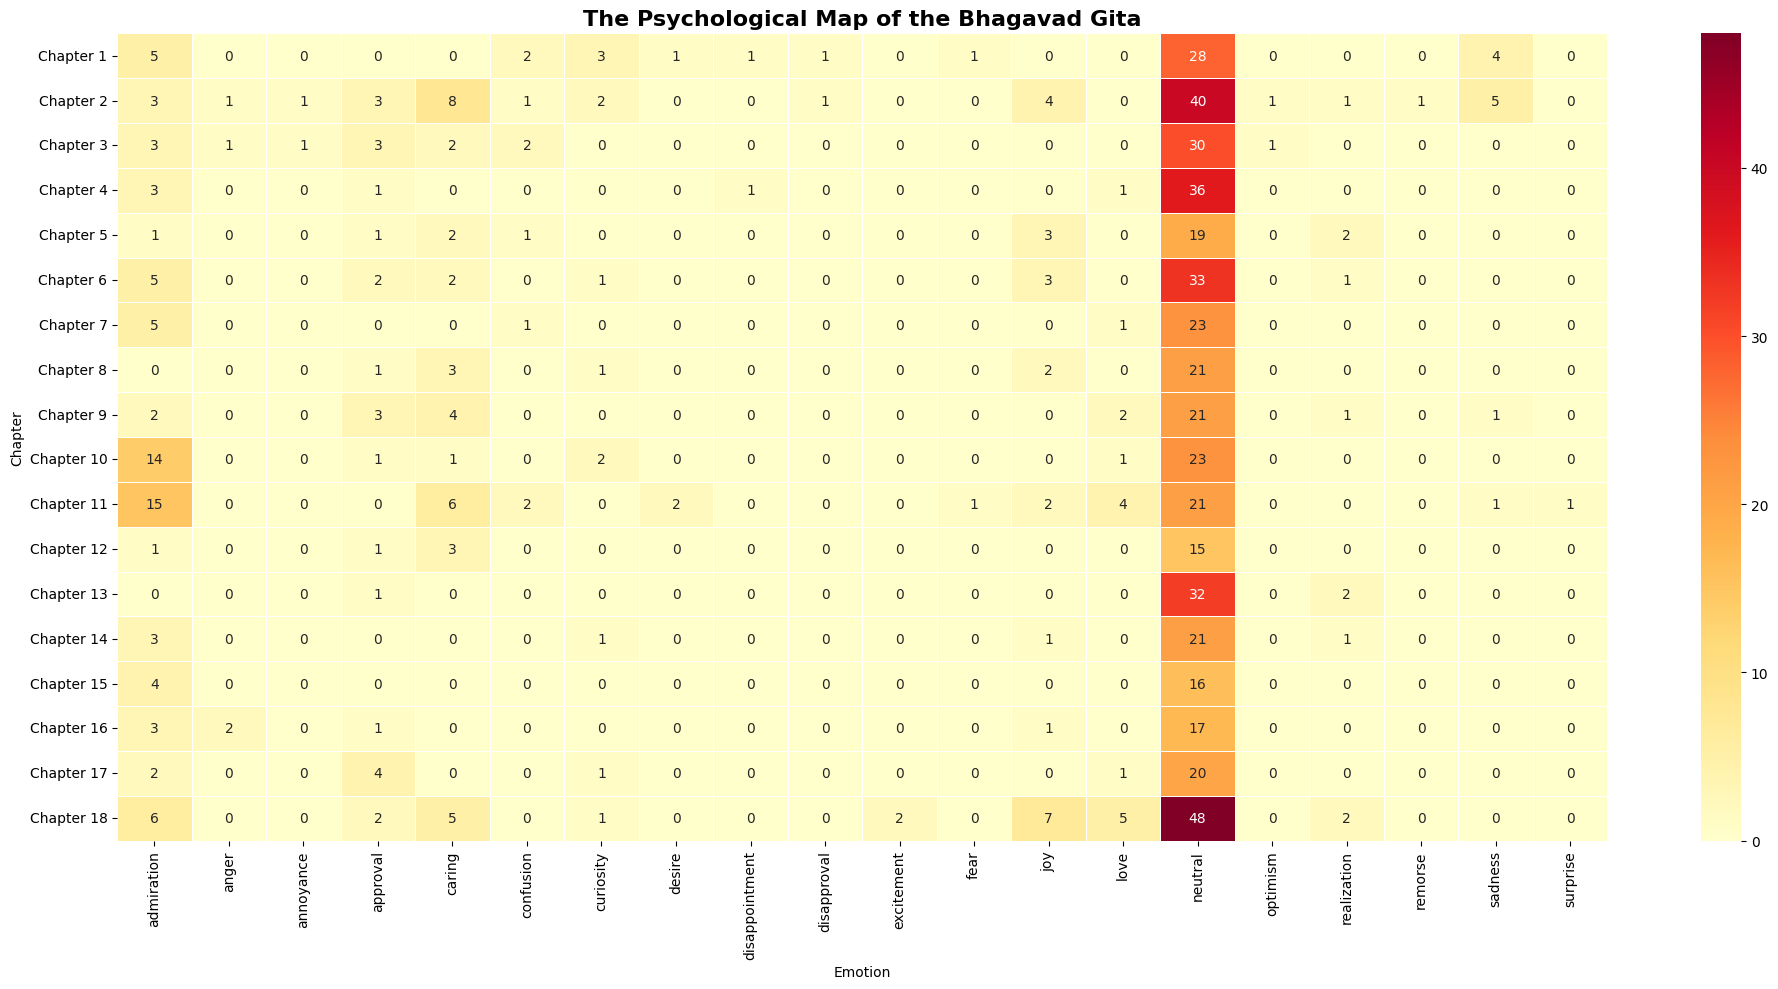

In [ ]:
from transformers import pipeline

emotion_classifier = pipeline(
    task='text-classification',
    model='SamLowe/roberta-base-go_emotions',
    top_k=None
)

# Run on all 700 verses — takes a few minutes
verse_list = a_english['Enlgish Translation'].astype(str).tolist()
raw_results = emotion_classifier(verse_list)

# Add top emotion per verse
a_english['emotion'] = [verse[0]['label'] for verse in raw_results]

# Build emotion matrix by chapter
emotion_matrix = pd.crosstab(a_english['Chapter'], a_english['emotion'])
chapter_order = sorted(emotion_matrix.index, key=lambda x: int(x.split(' ')[1]))
emotion_matrix = emotion_matrix.loc[chapter_order]

# Heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(emotion_matrix, cmap='YlOrRd', linewidths=0.5, annot=True, fmt='.0f')
plt.title('The Psychological Map of the Bhagavad Gita', fontsize=16, fontweight='bold')
plt.xlabel('Emotion')
plt.ylabel('Chapter')
plt.tight_layout()
plt.show()

In [ ]:
# sum of emotion graph like neutral is this much and ove is this much


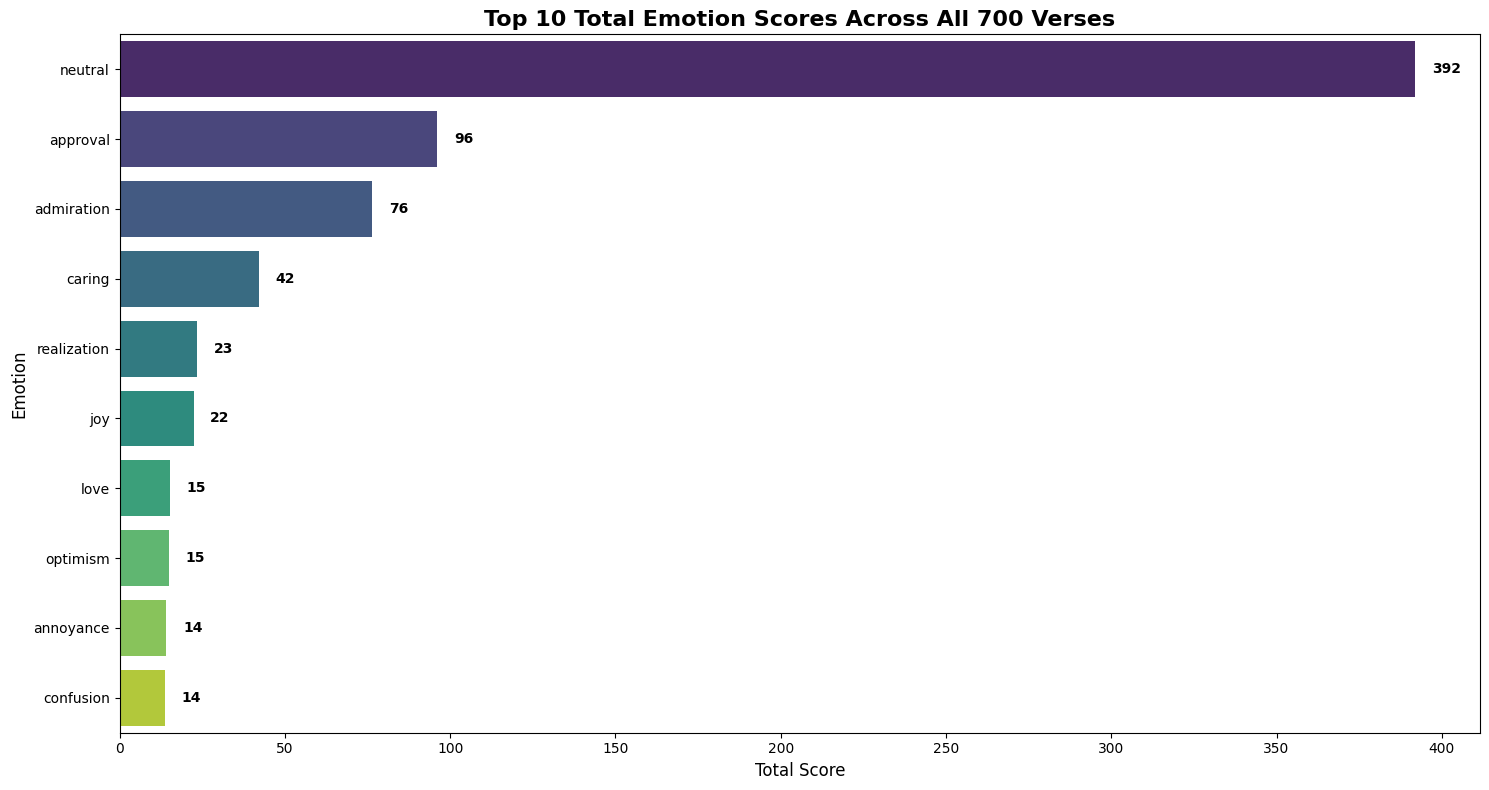

In [ ]:
emotion_rows_all = []
for verse_emotions in raw_results:
    row = {d['label']: d['score'] for d in verse_emotions}
    emotion_rows_all.append(row)

emotion_df_all = pd.DataFrame(emotion_rows_all)

# Sum the scores for each emotion across all verses and select top 10
total_emotion_scores = emotion_df_all.sum().sort_values(ascending=False).head(10)

# Plot the top 10 total emotion scores
plt.figure(figsize=(15, 8))
ax = sns.barplot(x=total_emotion_scores.values, y=total_emotion_scores.index, palette='viridis', hue=total_emotion_scores.index, legend=False)
plt.title('Top 10 Total Emotion Scores Across All 700 Verses', fontsize=16, fontweight='bold')
plt.xlabel('Total Score', fontsize=12)
plt.ylabel('Emotion', fontsize=12)
plt.xticks(rotation=0)

# Add annotations outside the bars at the end
for index, value in enumerate(total_emotion_scores.values):
    ax.text(value + 5, index, f'{value:.0f}', color='black', ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# **SECTION 6 — Krishna's Emotional Arc (GoEmotions, by chapter)**

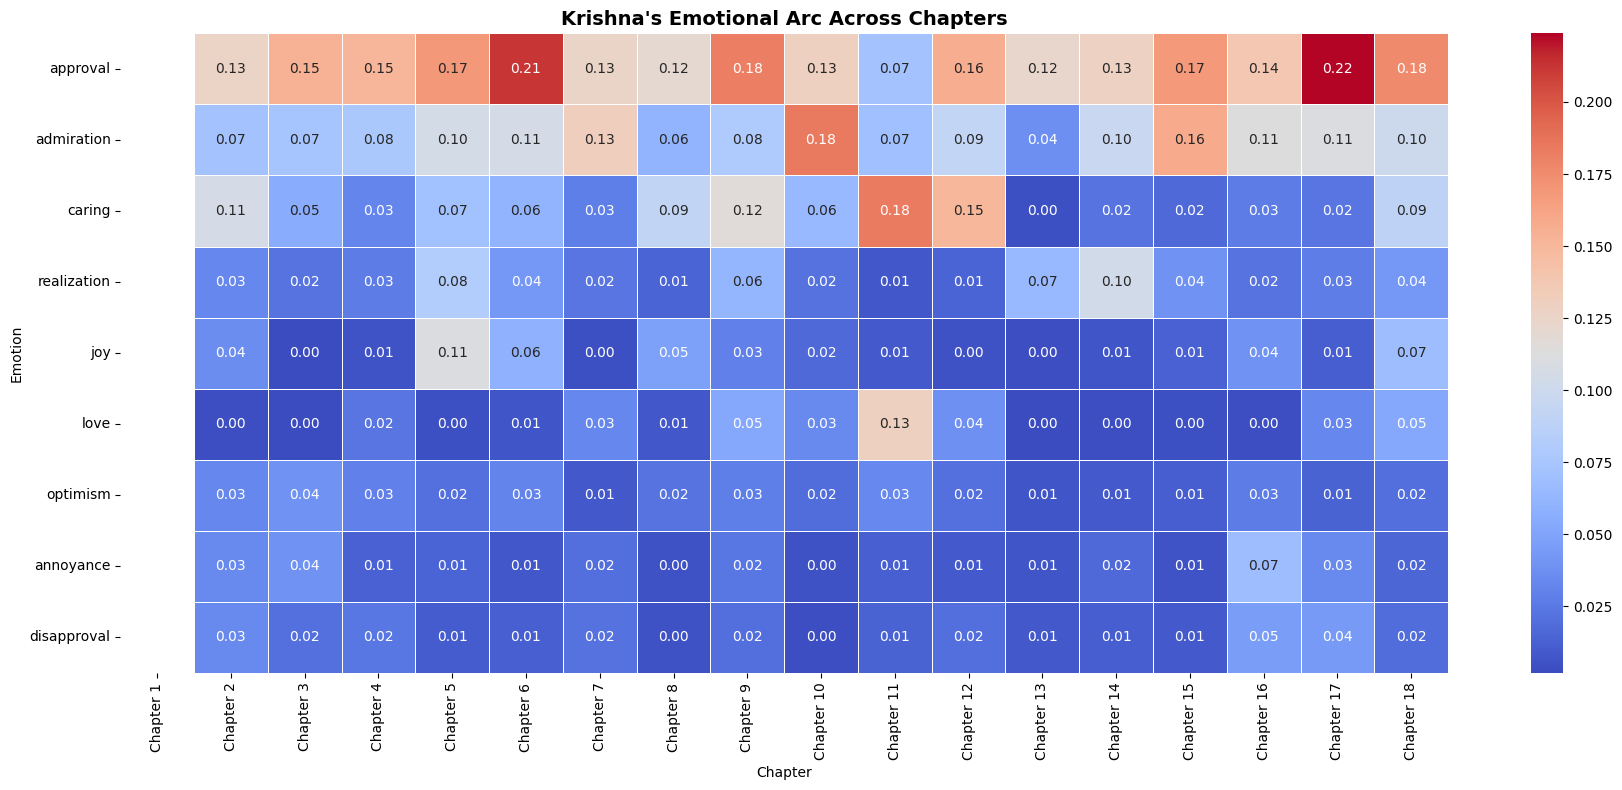

In [ ]:
# Krishna filtered using SPEAKER column — correct method
a_krishna = a_english[a_english['Speaker'] == 'Krishna'].copy()

krishna_emotions_raw = emotion_classifier(a_krishna['Enlgish Translation'].tolist())

# Build per-verse emotion scores (all 28 emotions)
emotion_rows_k = []
for verse_emotions in krishna_emotions_raw:
    row = {d['label']: d['score'] for d in verse_emotions}
    emotion_rows_k.append(row)

emotion_df_k = pd.DataFrame(emotion_rows_k)
emotion_df_k['Chapter'] = a_krishna['Chapter'].values

# Average by chapter
chapter_emotions_k = emotion_df_k.groupby('Chapter').mean(numeric_only=True)
chapter_emotions_k = chapter_emotions_k.reindex([f'Chapter {i}' for i in range(1, 19)])

# Top 9 emotions excluding neutral
top_k = chapter_emotions_k.mean().nlargest(10).index.tolist()
top_k_filtered = [e for e in top_k if e != 'neutral']

plt.figure(figsize=(18, 8))
sns.heatmap(
    chapter_emotions_k[top_k_filtered].T,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    linewidths=0.5
)
plt.title("Krishna's Emotional Arc Across Chapters", fontsize=14, fontweight='bold')
plt.xlabel('Chapter')
plt.ylabel('Emotion')
plt.tight_layout()
plt.show()

# **SECTION 7 — Arjuna's Emotional Arc**

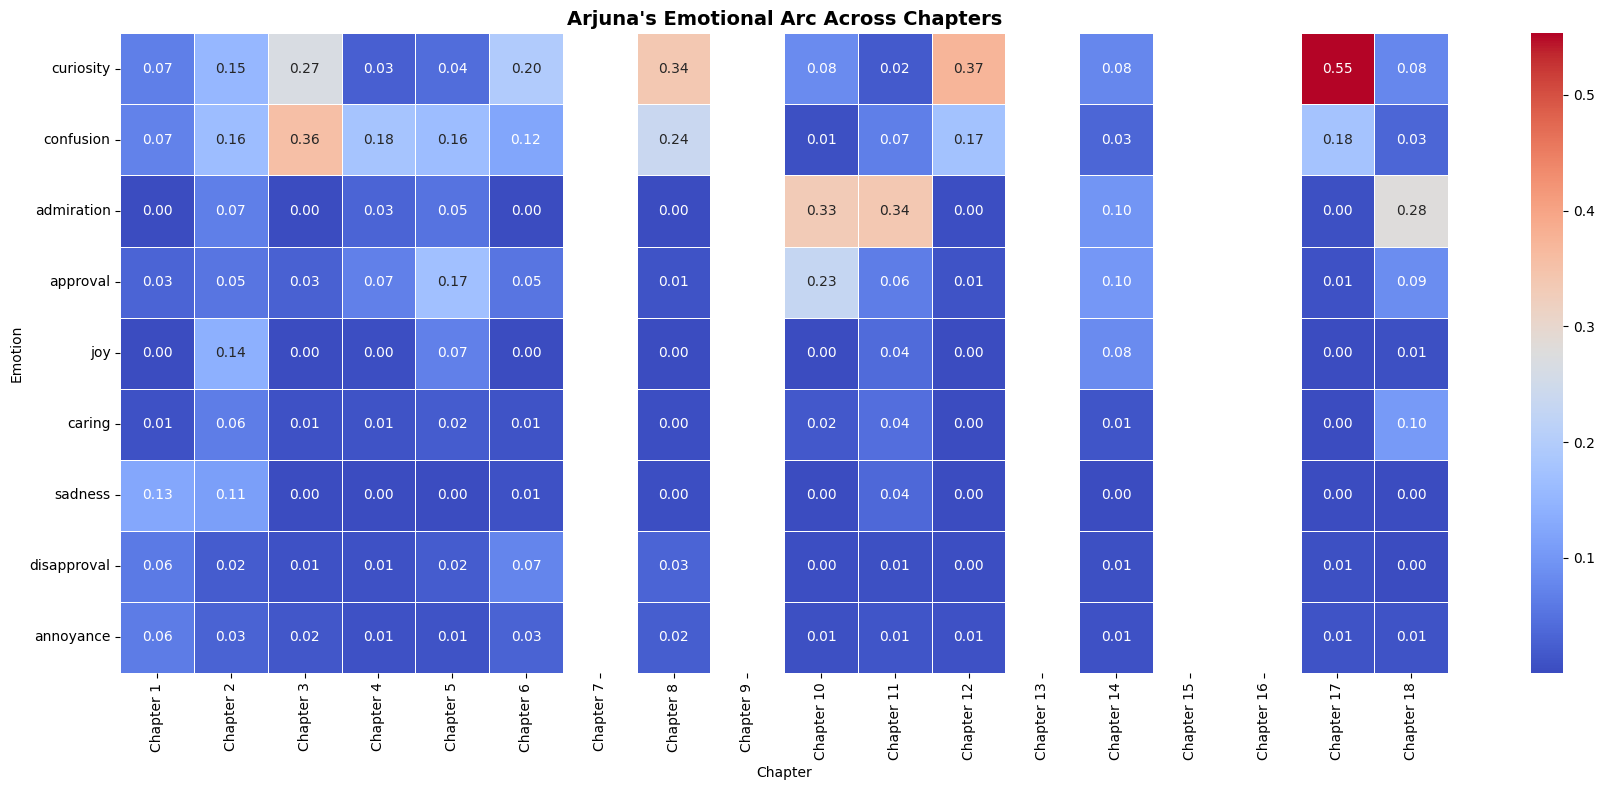

In [ ]:
a_arjuna = a_english[a_english['Speaker'] == 'Arjuna'].copy()

arjuna_emotions_raw = emotion_classifier(a_arjuna['Enlgish Translation'].tolist())

# Build per-verse emotion scores
emotion_rows_a = []
for verse_emotions in arjuna_emotions_raw:
    row = {d['label']: d['score'] for d in verse_emotions}
    emotion_rows_a.append(row)

emotion_df_a = pd.DataFrame(emotion_rows_a)
emotion_df_a['Chapter'] = a_arjuna['Chapter'].values

# Average by chapter
chapter_emotions_a = emotion_df_a.groupby('Chapter').mean(numeric_only=True)
chapter_emotions_a = chapter_emotions_a.reindex([f'Chapter {i}' for i in range(1, 19)])

# Top 9 emotions excluding neutral
top_a = chapter_emotions_a.mean().nlargest(10).index.tolist()
top_a_filtered = [e for e in top_a if e != 'neutral']

plt.figure(figsize=(18, 8))
sns.heatmap(
    chapter_emotions_a[top_a_filtered].T,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    linewidths=0.5
)
plt.title("Arjuna's Emotional Arc Across Chapters", fontsize=14, fontweight='bold')
plt.xlabel('Chapter')
plt.ylabel('Emotion')
plt.tight_layout()
plt.show()

# **SECTION 8 — LDA Thematic Analysis**

In [ ]:
!pip install gensim

import nltk
from nltk.stem import WordNetLemmatizer
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

nltk.download('wordnet')
nltk.download('omw-1.4')

# Group all verses by chapter
a2 = a[['Chapter', 'Verse', 'Enlgish Translation']]
chapters_docs = a2.groupby('Chapter')['Enlgish Translation'].agg(lambda x: ' '.join(x)).reset_index()
chapters_docs['Chapter_Num'] = chapters_docs['Chapter'].str.extract(r'(\d+)').astype(int)
chapters_docs = chapters_docs.sort_values(by='Chapter_Num').drop(columns='Chapter_Num')

# Stopwords and cleaning
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
gita_noise = {
    'arjuna', 'krishna', 'sanjaya', 'dhritarashtra', 'kurukshetra',
    'duryodhana', 'bhishma', 'drona', 'bharata', 'partha', 'kaunteya',
    'madhusudana', 'thou', 'thy', 'thee', 'thine', 'hath', 'doth',
    'verily', 'shall', 'unto', 'upon', 'thus', 'said', 'dear', 'lord',
    'great', 'also', 'even', 'like', 'well', 'must', 'ever', 'know',
    'that', 'this', 'these', 'those', 'come', 'become', 'attain'
}
stop_words.update(gita_noise)

def cleaning(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words_list = text.split()
    cleaned = [
        lemmatizer.lemmatize(w)
        for w in words_list
        if w not in stop_words and len(w) > 2
    ]
    return cleaned

cleaned_docs = [cleaning(text) for text in chapters_docs['Enlgish Translation'].values]

# Dictionary and corpus
dictionary = corpora.Dictionary(cleaned_docs)
dictionary.filter_extremes(no_below=2, no_above=0.85)
corpus = [dictionary.doc2bow(doc) for doc in cleaned_docs]

print(f"Dictionary size: {len(dictionary)} words")
print(f"Corpus: {len(corpus)} documents (chapters)")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Dictionary size: 1140 words
Corpus: 18 documents (chapters)


N= 2  coherence=0.2628
N= 3  coherence=0.2804
N= 4  coherence=0.2801
N= 5  coherence=0.3119
N= 6  coherence=0.3084
N= 7  coherence=0.2956
N= 8  coherence=0.3493
N= 9  coherence=0.3152
N=10  coherence=0.3138
N=11  coherence=0.3031
N=12  coherence=0.3462
N=13  coherence=0.3405
N=14  coherence=0.3246
N=15  coherence=0.3172
N=16  coherence=0.3064
N=17  coherence=0.2758
N=18  coherence=0.3043
N=19  coherence=0.3136
N=20  coherence=0.2939


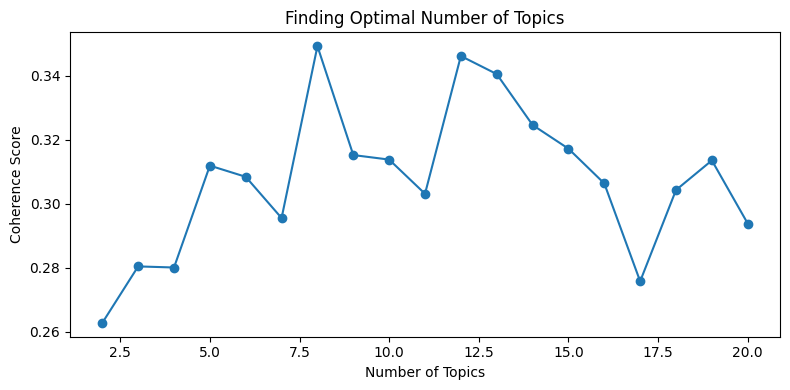

In [ ]:
# Find optimal number of topics using coherence score
coherence_scores = []

for n in range(2, 21):  # Changed to calculate scores for n from 2 to 20
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=n,
        random_state=42,
        passes=10
    )
    coherence_model = CoherenceModel(
        model=lda_model,
        texts=cleaned_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    score = coherence_model.get_coherence()
    coherence_scores.append(score)
    print(f"N={n:2d}  coherence={score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(2, 21), coherence_scores, 'o-') # Now this range matches the calculated scores
plt.xlabel('Number of Topics')
plt.ylabel('Coherence Score')
plt.title('Finding Optimal Number of Topics')
plt.tight_layout()
plt.show()

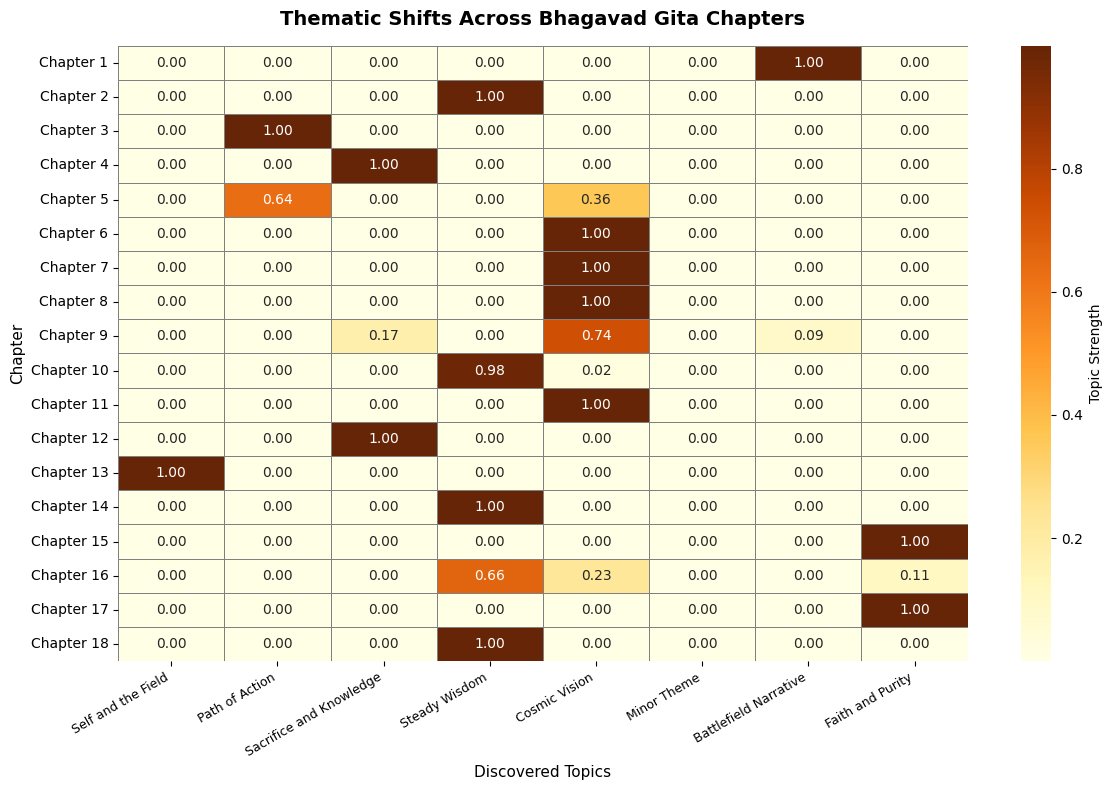

In [ ]:
# Train final LDA model with 7 topics
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=8,
    random_state=42,
    passes=10
)

topic_names = {
    0: "Self and the Field",
    1: "Path of Action",
    2: "Sacrifice and Knowledge",
    3: "Steady Wisdom",
    4: "Cosmic Vision",
    5: "Minor Theme",
    6: "Battlefield Narrative",
    7: "Faith and Purity"
}

# Get topic distribution per chapter
doc_topics = []
for doc in corpus:
    topic_dist = lda_model.get_document_topics(doc, minimum_probability=0)
    topic_probs = [prob for _, prob in sorted(topic_dist)]
    doc_topics.append(topic_probs)

topic_df = pd.DataFrame(
    doc_topics,
    columns=[topic_names[i] for i in range(8)],
    index=chapters_docs['Chapter'].values
)

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    topic_df,
    annot=True,
    fmt='.2f',
    cmap='YlOrBr',
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Topic Strength'}
)
plt.title('Thematic Shifts Across Bhagavad Gita Chapters',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Discovered Topics', fontsize=11)
plt.ylabel('Chapter', fontsize=11)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

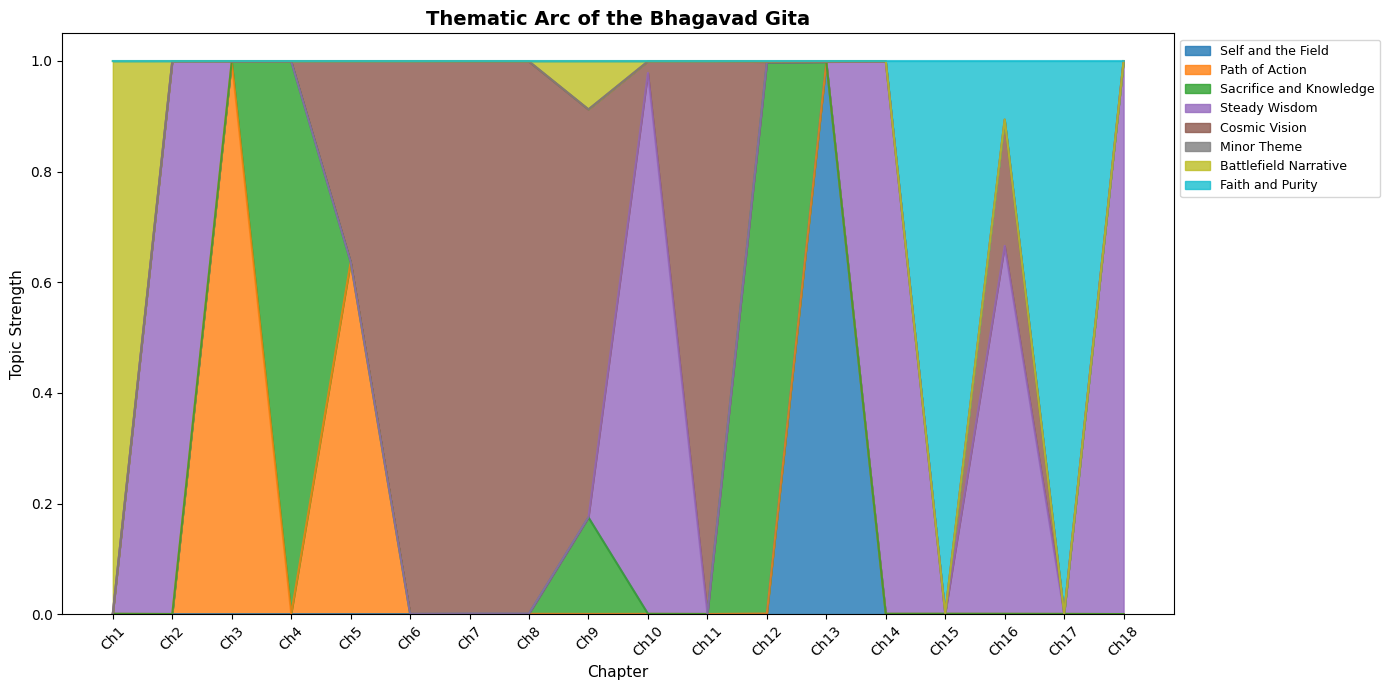

In [ ]:
# Stacked area chart — thematic arc
topic_df.plot(
    kind='area',
    stacked=True,
    figsize=(14, 7),
    colormap='tab10',
    alpha=0.8
)
plt.title('Thematic Arc of the Bhagavad Gita', fontsize=14, fontweight='bold')
plt.xlabel('Chapter', fontsize=11)
plt.ylabel('Topic Strength', fontsize=11)
plt.xticks(ticks=range(18), labels=[f'Ch{i+1}' for i in range(18)], rotation=45)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)
plt.tight_layout()
plt.show()

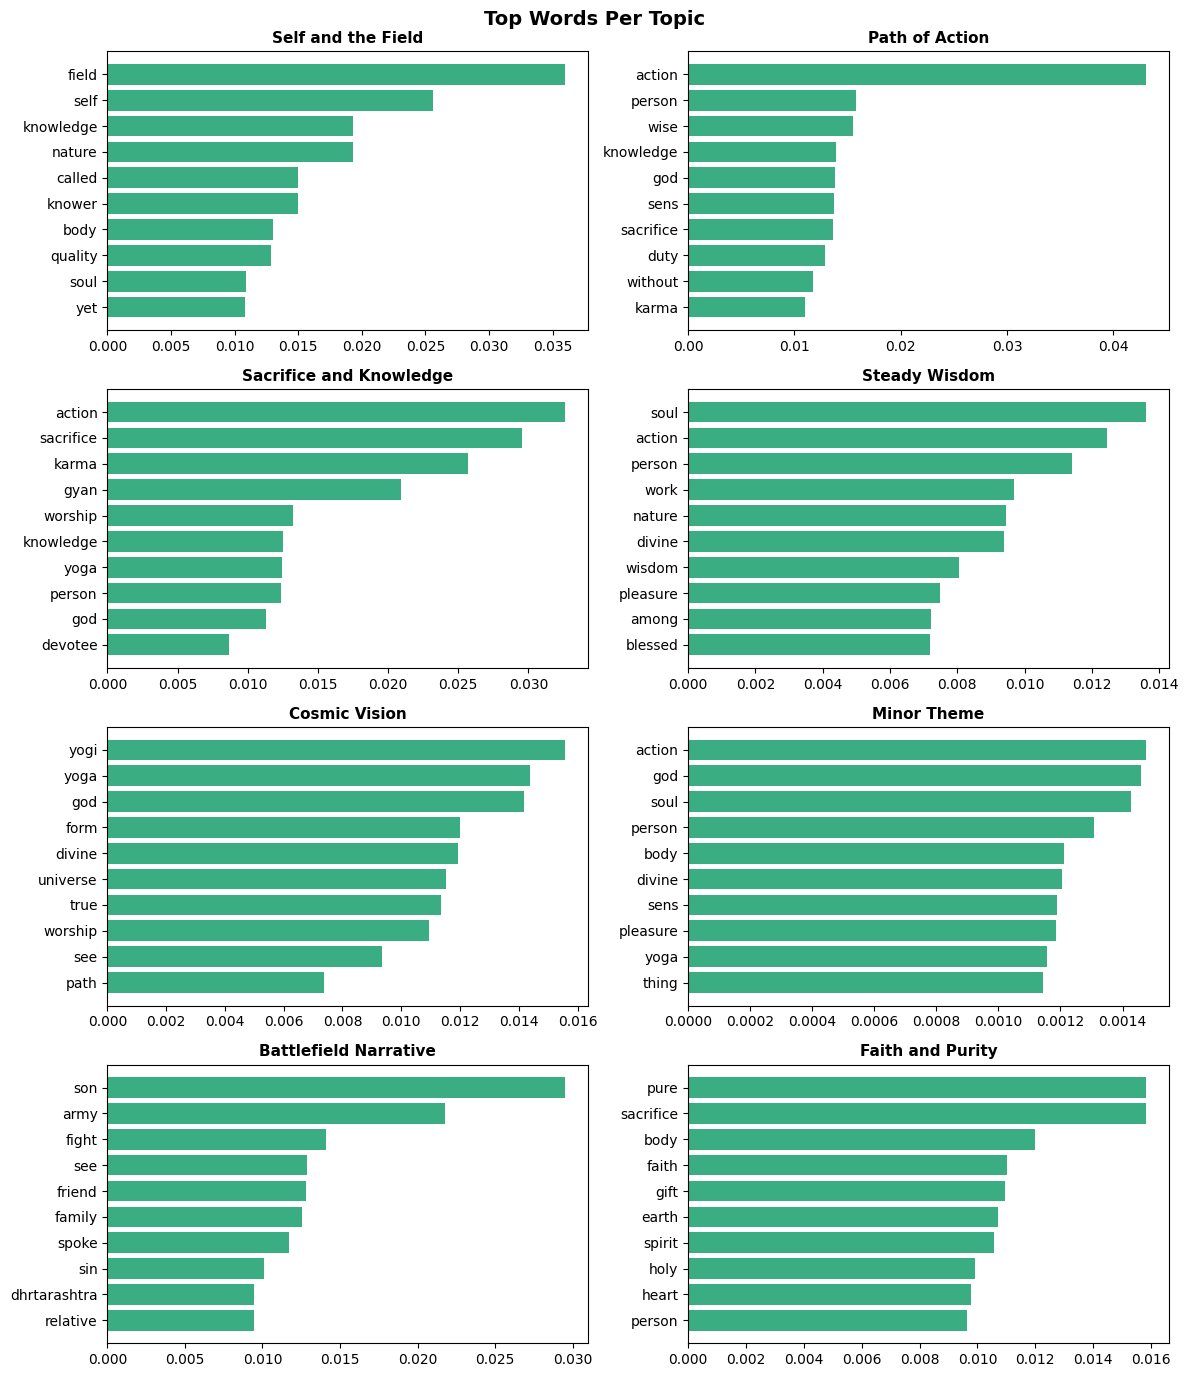

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()

for i in range(8):
    words_weights = lda_model.show_topic(i, topn=10)
    words = [pair[0] for pair in words_weights]
    weights = [pair[1] for pair in words_weights]
    axes[i].barh(words, weights, color='#3BAD83')
    axes[i].set_title(topic_names[i], fontsize=11, fontweight='bold')
    axes[i].invert_yaxis()

plt.suptitle('Top Words Per Topic', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# **SECTION 9 — Readability Analysis**


In [ ]:
!pip install textstat
import textstat

a2 = a[['Chapter', 'Verse', 'Enlgish Translation']].copy()
a2['Grade_Level'] = a2['Enlgish Translation'].astype(str).apply(textstat.flesch_kincaid_grade)
a2['Chapter_num'] = a2['Chapter'].str.extract(r'(\d+)').astype(int)
a2 = a2.sort_values(by='Chapter_num')

a3_df = a2.groupby('Chapter_num')['Grade_Level'].mean().reset_index()

fig = px.line(
    a3_df,
    x='Chapter_num',
    y='Grade_Level',
    markers=True,
    title='Reading Complexity Across Chapters (Flesch-Kincaid Grade Level)',
    labels={'Chapter_num': 'Chapter', 'Grade_Level': 'Grade Level'}
)

fig.update_traces(line=dict(color='chocolate', width=2), marker=dict(symbol='square'))

highest = a3_df.loc[a3_df['Grade_Level'].idxmax()]
fig.add_annotation(
    x=highest['Chapter_num'],
    y=highest['Grade_Level'],
    text=f"Highest: {highest['Grade_Level']:.1f}",
    arrowhead=1,
    yshift=10,
    showarrow=True
)

fig.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 10.1 MB/s eta 0:00:00


In [ ]:
#print the values of reading level
print(a3_df)

    Chapter_num  Grade_Level
0             1    11.102650
1             2    11.201729
2             3    10.483475
3             4    11.578343
4             5    13.661967
5             6    11.877969
6             7    12.381230
7             8    12.931588
8             9    12.657584
9            10    10.393099
10           11    11.094635
11           12    13.381933
12           13    11.648093
13           14    13.712054
14           15    14.486587
15           16    12.259951
16           17    16.234623
17           18    14.779140
